In [2]:
## 4.1 — Embedding & Similarity
!pip install sentence-transformers seaborn matplotlib


In [3]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. Defining 10 sentences across 3 topics:
sentences = [
    #Cricket:
    "Cricket is one most favourite games for Indians",
    "Fast Bowlers relay on phase(especially Yoker) or swing to take wickets",
    "1st Century would a ever green mile stone for each bastman",
    "IPL paved new way find new talents to international games",
    #Cooking:
    "Cooking is the necessary art for living",
    "Chop vegetable to small and even pieces"
    "preheat the oven before baking",
    #CyberSecurity:
    "Multi-Factor attentication acts critical security layer on online banking",
    "Phusing attacks often uses deceptive email to steal the credentials",
    "Cyber Security is not set of products -but it's set of practices"
]
print(sentences)


['Cricket is one most favourite games for Indians', 'Fast Bowlers relay on phase(especially Yoker) or swing to take wickets', '1st Century would a ever green mile stone for each bastman', 'IPL paved new way find new talents to international games', 'Cooking is the necessary art for living', 'Chop vegetable to small and even piecespreheat the oven before baking', 'Multi-Factor attentication acts critical security layer on online banking', 'Phusing attacks often uses deceptive email to steal the credentials', "Cyber Security is not set of products -but it's set of practices"]


In [4]:
# 2. Generating embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

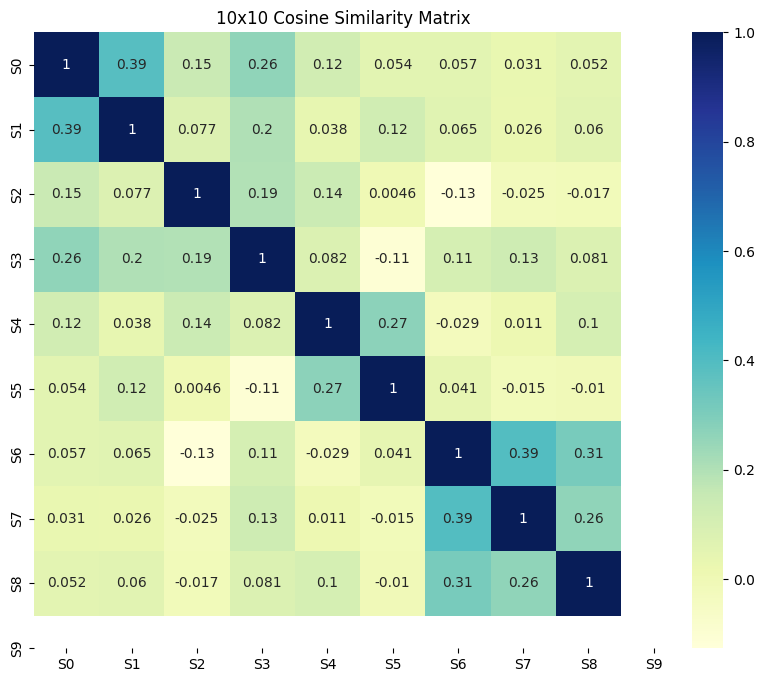

In [7]:
# 3. Compute 10x10 Cosine Similarity Matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

# Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.cpu().numpy(), annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i}" for i in range(10)],
            yticklabels=[f"S{i}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [8]:
# 4. Query: Top 2 most similar sentences
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity between query and all sentences
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"Query: {query}\n")
for hit in hits[0]:
    print(f"Score: {hit['score']:.4f} | Sentence: {sentences[hit['corpus_id']]}")

Query: The bowler took three wickets in one over

Score: 0.4977 | Sentence: Fast Bowlers relay on phase(especially Yoker) or swing to take wickets
Score: 0.4036 | Sentence: Cricket is one most favourite games for Indians
